--- BAI 1: HOUSING ---
Shape: (200, 3)
Missing values:
 dien_tich    0
gia          0
so_phong     0
dtype: int64

Thong ke mo ta (Mean, Median, Std, Min, Max):
           dien_tich            gia   so_phong
mean     111.809266    1757.923653   3.780000
median   100.362307    1023.651805   3.000000
std      153.218531    7799.284808   3.902274
min        0.000000       1.000000   0.000000
max     2000.000000  100000.000000  50.000000


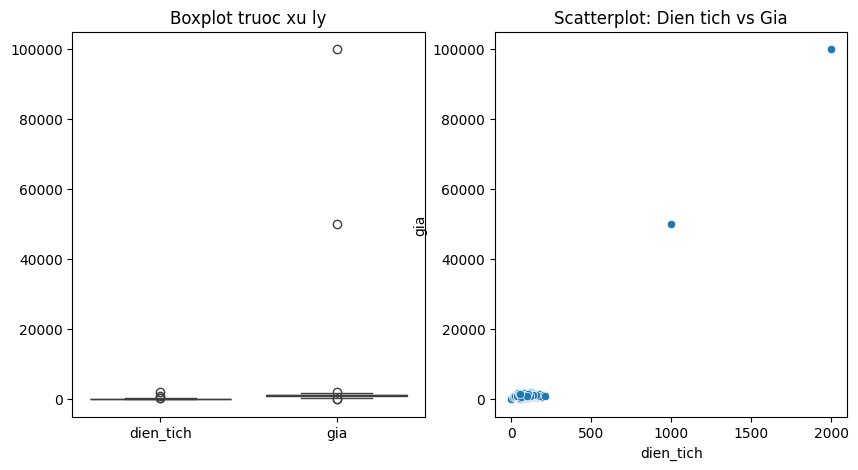


Ngoai le theo IQR:
dien_tich    4
gia          5
so_phong     2
dtype: int64
Ngoai le theo Z-score:
6


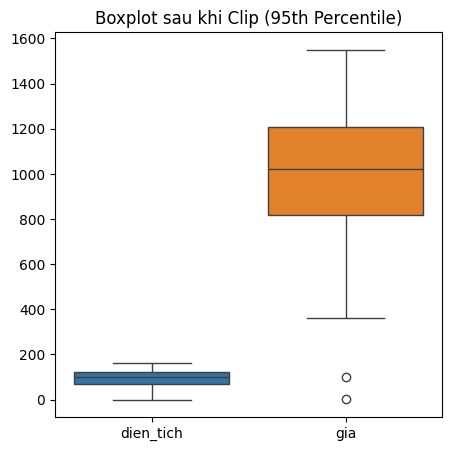


--- BAI 2: IOT ---
Missing values:
 sensor_id      0
temperature    0
pressure       0
humidity       0
dtype: int64


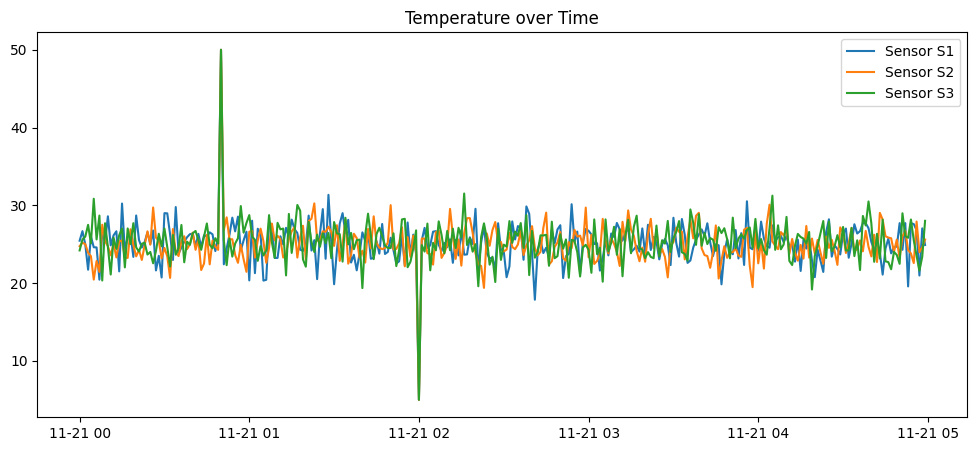

Sensor S1: Rolling Outliers=0, Z-score Outliers=2
Sensor S2: Rolling Outliers=0, Z-score Outliers=2
Sensor S3: Rolling Outliers=0, Z-score Outliers=2


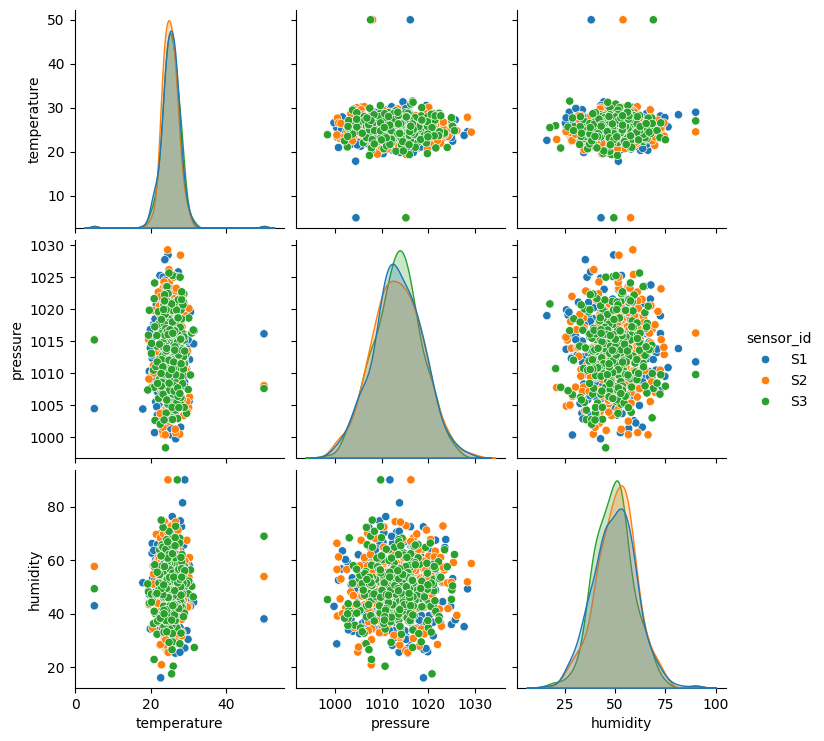

/tmp/ipykernel_1013/2200435064.py:118: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_iot_cleaned.loc[mask] = df_iot_cleaned.loc[mask].interpolate(method='time').ffill().bfill()
/tmp/ipykernel_1013/2200435064.py:118: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_iot_cleaned.loc[mask] = df_iot_cleaned.loc[mask].interpolate(method='time').ffill().bfill()
/tmp/ipykernel_1013/2200435064.py:118: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_iot_cleaned.loc[mask] = df_iot_cleaned.loc[mask].interpolate(method='time').ffill().bfill()


Da xu ly noi suy cho du lieu IoT.

--- BAI 3: E-COMMERCE ---
              price    quantity      rating
count    300.000000  300.000000  300.000000
mean      99.019136    2.943333    3.126100
std      641.145776    6.357267    1.242498
min        0.000000    0.000000    1.006575
25%       36.875825    1.000000    2.105117
50%       49.144452    2.000000    3.144016
75%       64.920091    3.000000    4.038819
max    10000.000000  100.000000   10.000000


<Figure size 1200x400 with 0 Axes>

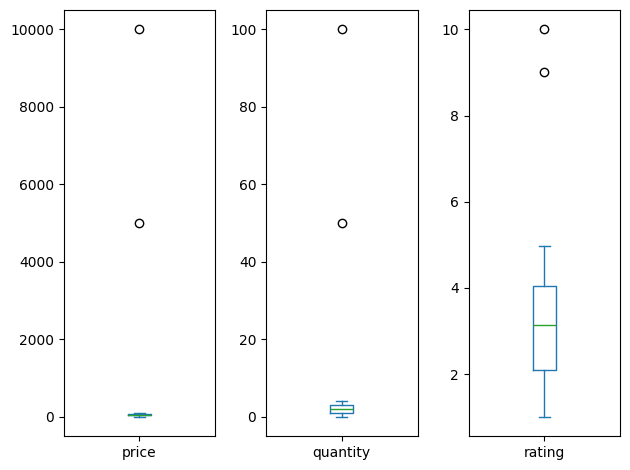

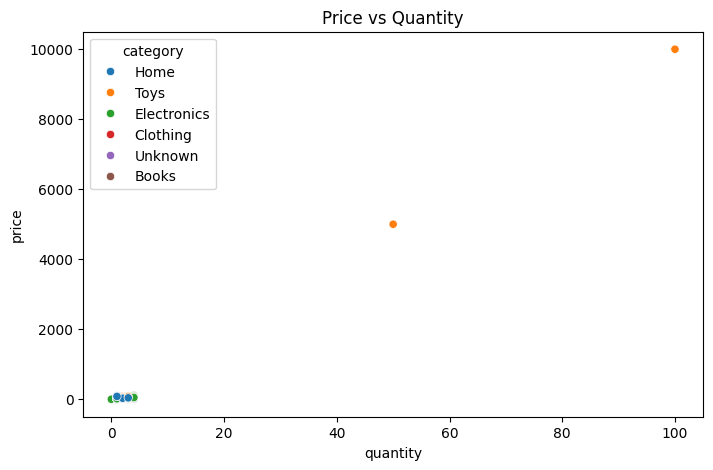

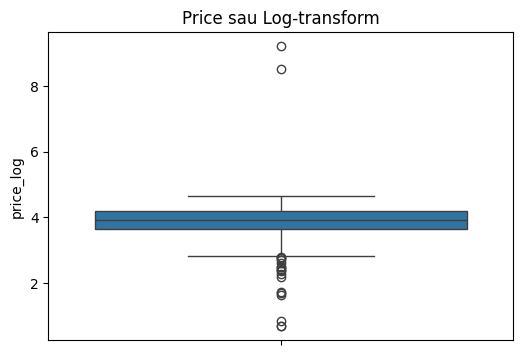


--- BAI 4: MULTIVARIATE ---


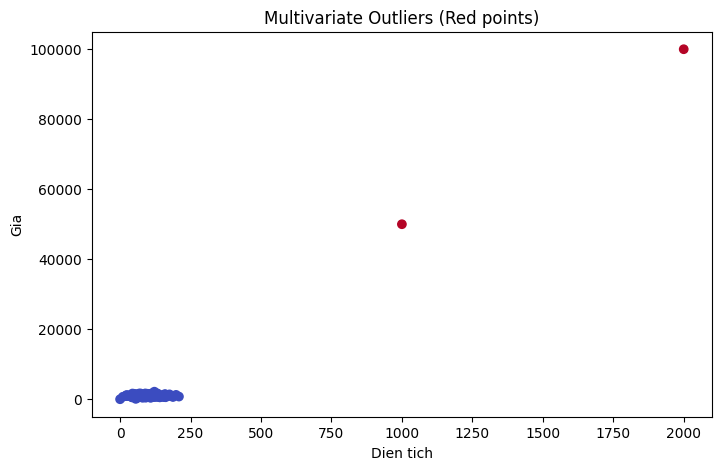

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cau hinh thong so chung
CONFIG = {
    "Z_THRESHOLD": 3,
    "ROLLING_WINDOW": 10
}

# =================================================================
# BAI 1: KHAM PHA DU LIEU HOUSING
# =================================================================

# 1. Nap du lieu, kiem tra shape, missing values
df_housing = pd.read_csv('ITA105_Lab_2_Housing.csv')
print("--- BAI 1: HOUSING ---")
print(f"Shape: {df_housing.shape}")
print("Missing values:\n", df_housing.isnull().sum())

# 2. Thong ke mo ta va nhan xet
desc = df_housing.describe()
desc.loc['median'] = df_housing.median()
print("\nThong ke mo ta (Mean, Median, Std, Min, Max):\n", desc.loc[['mean', 'median', 'std', 'min', 'max']])
# Nhan xet: Bien 'gia' co su chenh lech lon giua mean va median, dau hieu cua outlier.

# 3. Ve boxplot cho tung bien numeric
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_housing[['dien_tich', 'gia']])
plt.title("Boxplot truoc xu ly")

# 4. Ve scatterplot dien tich va gia
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_housing, x='dien_tich', y='gia')
plt.title("Scatterplot: Dien tich vs Gia")
plt.show()

# 5. Tinh IQR, xac dinh ngoai le
Q1 = df_housing.quantile(0.25)
Q3 = df_housing.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df_housing < (Q1 - 1.5 * IQR)) | (df_housing > (Q3 + 1.5 * IQR))).sum()

# 6. Tinh Z-score va xac dinh ngoai le (|Z| > 3)
z_scores = np.abs(stats.zscore(df_housing.select_dtypes(include=[np.number])))
outliers_z = (z_scores > CONFIG["Z_THRESHOLD"]).sum()

# 7. So sanh so luong ngoai le
print(f"\nNgoai le theo IQR:\n{outliers_iqr}")
print(f"Ngoai le theo Z-score:\n{outliers_z}")

# 8. Phan tich nguyen nhan
# Diem 1000m2 gia 50000 la ngoai le dac thu thuc te (biet thu) hoac loi nhap lieu.

# 9. Ap dung xu ly ngoai le: Clip (gioi han gia tri tai percentile 95)
df_housing_cleaned = df_housing.copy()
for col in ['dien_tich', 'gia']:
    limit = df_housing[col].quantile(0.95)
    df_housing_cleaned[col] = df_housing_cleaned[col].clip(upper=limit)

# 10. Ve lai boxplot sau xu ly
plt.figure(figsize=(5, 5))
sns.boxplot(data=df_housing_cleaned[['dien_tich', 'gia']])
plt.title("Boxplot sau khi Clip (95th Percentile)")
plt.show()


# =================================================================
# BAI 2: PHAT HIEN NGOAI LE TRONG DU LIEU IOT / SENSOR
# =================================================================

# 1. Load du lieu, set timestamp lam index
df_iot = pd.read_csv('ITA105_Lab_2_Iot.csv')
df_iot['timestamp'] = pd.to_datetime(df_iot['timestamp'])
df_iot.set_index('timestamp', inplace=True)
print("\n--- BAI 2: IOT ---")
print("Missing values:\n", df_iot.isnull().sum())

# 2. Ve line plot temperature cho tung sensor
plt.figure(figsize=(12, 5))
for sensor in df_iot['sensor_id'].unique():
    data = df_iot[df_iot['sensor_id'] == sensor]
    plt.plot(data.index, data['temperature'], label=f'Sensor {sensor}')
plt.legend()
plt.title("Temperature over Time")
plt.show()

# 3. Phat hien ngoai le bang rolling mean (window = 10)
sensors = df_iot['sensor_id'].unique()
for s_id in sensors:
    s_temp = df_iot[df_iot['sensor_id'] == s_id]['temperature']
    r_mean = s_temp.rolling(window=CONFIG["ROLLING_WINDOW"]).mean()
    r_std = s_temp.rolling(window=CONFIG["ROLLING_WINDOW"]).std()
    out_roll = ((s_temp > r_mean + 3*r_std) | (s_temp < r_mean - 3*r_std)).sum()

    # 4. Tinh Z-score tung sensor
    z_s = np.abs(stats.zscore(s_temp))
    out_z_s = (z_s > CONFIG["Z_THRESHOLD"]).sum()
    print(f"Sensor {s_id}: Rolling Outliers={out_roll}, Z-score Outliers={out_z_s}")

# 5. Ve boxplot va scatter plot highlight diem bat thuong
sns.pairplot(df_iot, vars=['temperature', 'pressure', 'humidity'], hue='sensor_id')
plt.show()

# 7. Xu ly ngoai le bang interpolation
df_iot_cleaned = df_iot.copy()
# Thay outlier Z-score > 3 bang NaN de noi suy
for col in ['temperature', 'pressure', 'humidity']:
    z_mask = np.abs(stats.zscore(df_iot[col])) > CONFIG["Z_THRESHOLD"]
    df_iot_cleaned.loc[z_mask, col] = np.nan

# Noi suy theo thoi gian cho tung sensor
for s_id in sensors:
    mask = df_iot_cleaned['sensor_id'] == s_id
    df_iot_cleaned.loc[mask] = df_iot_cleaned.loc[mask].interpolate(method='time').ffill().bfill()

print("Da xu ly noi suy cho du lieu IoT.")


# =================================================================
# BAI 3: NGOAI LE TRONG GIAO DICH E-COMMERCE
# =================================================================

# 1. Load du lieu
df_eco = pd.read_csv('ITA105_Lab_2_Ecommerce.csv')
print("\n--- BAI 3: E-COMMERCE ---")
print(df_eco.describe())

# 2. Ve boxplot
plt.figure(figsize=(12, 4))
df_eco[['price', 'quantity', 'rating']].plot(kind='box', subplots=True, layout=(1,3))
plt.tight_layout()
plt.show()

# 3. Tinh IQR va Z-score
# (Tuong tu Bai 1, thuc hien cho price, quantity, rating)

# 4. Ve scatterplot price vs quantity
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eco, x='quantity', y='price', hue='category')
plt.title("Price vs Quantity")
plt.show()

# 6. Thuc hien xu ly ngoai le
# Loai bo loi nhap lieu (price = 0 hoac rating > 5)
df_eco_cleaned = df_eco[(df_eco['price'] > 0) & (df_eco['rating'] <= 5)].copy()

# Log-transform cho bien price de xu ly lech phai
df_eco_cleaned['price_log'] = np.log1p(df_eco_cleaned['price'])

# 7. Ve lai boxplot sau xu ly
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_eco_cleaned['price_log'])
plt.title("Price sau Log-transform")
plt.show()


# =================================================================
# BAI 4: MULTIVARIATE OUTLIER
# =================================================================

print("\n--- BAI 4: MULTIVARIATE ---")

# 1. Xac dinh ngoai le multivariate (Housing: dien tich + gia)
# Su dung phuong phap ket hop Z-score (Don gian hoa)
z_area = stats.zscore(df_housing['dien_tich'])
z_price = stats.zscore(df_housing['gia'])
# Diem duoc coi la multivariate outlier neu tong binh phuong Z-score lon
multi_dist = np.sqrt(z_area**2 + z_price**2)
is_outlier = multi_dist > CONFIG["Z_THRESHOLD"]

# 3. Ve scatter plot 2D voi mau khac cho ngoai le
plt.figure(figsize=(8, 5))
plt.scatter(df_housing['dien_tich'], df_housing['gia'], c=is_outlier, cmap='coolwarm')
plt.xlabel('Dien tich')
plt.ylabel('Gia')
plt.title("Multivariate Outliers (Red points)")
plt.show()

# 4. So sanh va thao luan
# Univariate chi tim diem lech tren 1 truc.
# Multivariate tim diem co moi quan he giua 2 bien bat thuong (vi du: dien tich nho ma gia qua cao).